In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import pandas as pd
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

In [3]:
elev = xr.open_dataset("/global/homes/r/rudisill/gshare2/will_data/global_ceres/CERES_SYN1deg-Month_Terra-Aqua-MODIS_Ed4.1_Subset_202311-202312.nc")
cds = xr.open_mfdataset("/global/homes/r/rudisill/gshare2/will_data/global_ceres/CERES_SYN1deg-Day_Terra-Aqua-MODIS_Ed4.1_Subset_*nc")

In [4]:
ocean = xr.open_dataset("/global/homes/r/rudisill/gshare2/will_data/global_ceres/CERES_SYN1deg-Month_Terra-Aqua-MODIS_Ed4.1_Subset_202402-202402.nc").aux_ocean_mon

In [5]:
sfc_elev_mon = elev.sfc_elev_mon.isel(time=0)

In [6]:
cre_sw = cds.adj_atmos_sw_down_all_surface_daily - cds.adj_atmos_sw_down_clr_surface_daily
cre_lw = cds.adj_atmos_lw_down_all_surface_daily - cds.adj_atmos_lw_down_clr_surface_daily


In [7]:
crf_sw = (cds.adj_atmos_sw_down_all_surface_daily - cds.adj_atmos_sw_up_all_surface_daily) - (cds.adj_atmos_sw_down_clr_surface_daily - cds.adj_atmos_sw_up_clr_surface_daily) 

In [8]:
albedo = cds.adj_atmos_sw_up_all_surface_daily / cds.adj_atmos_sw_down_all_surface_daily

In [9]:
crf_lw = (cds.adj_atmos_lw_down_all_surface_daily - cds.adj_atmos_lw_up_all_surface_daily) - (cds.adj_atmos_lw_down_clr_surface_daily - cds.adj_atmos_lw_up_clr_surface_daily) 

In [10]:
avg_cloud = cds.cldarea_total_daily.mean(dim='time').compute()

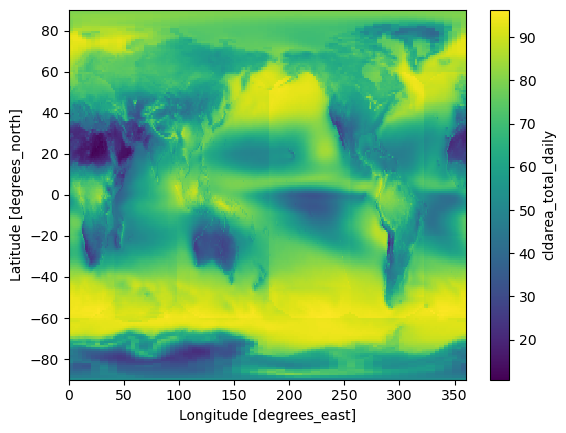

In [11]:
avg_cloud.plot()

In [12]:
crf_net = crf_sw + crf_lw

In [13]:
cre_net = cre_sw + cre_lw
crf_net_mean = crf_net.mean(dim='time').compute()

### compte CRF for various times...

In [14]:
cold_season_crf_net = crf_net.sel(time=crf_net.time.dt.month.isin([10,11,12,1,2,3])).mean(dim='time').compute()

In [15]:
warm_season_crf_net = crf_net.sel(time=crf_net.time.dt.month.isin([4,5,6,7,8,9])).mean(dim='time').compute()

In [16]:
cold_season_crf_lw = crf_lw .sel(time=cre_lw.time.dt.month.isin([10,11,12,1,2,3])).mean(dim='time').compute()

In [17]:
warm_season_crf_lw = crf_lw.sel(time=crf_net.time.dt.month.isin([4,5,6,7,8,9])).mean(dim='time').compute()

In [18]:
cold_season_crf_sw = crf_sw.sel(time=cre_lw.time.dt.month.isin([10,11,12,1,2,3])).mean(dim='time').compute()
warm_season_crf_sw = crf_sw.sel(time=crf_net.time.dt.month.isin([4,5,6,7,8,9])).mean(dim='time').compute()

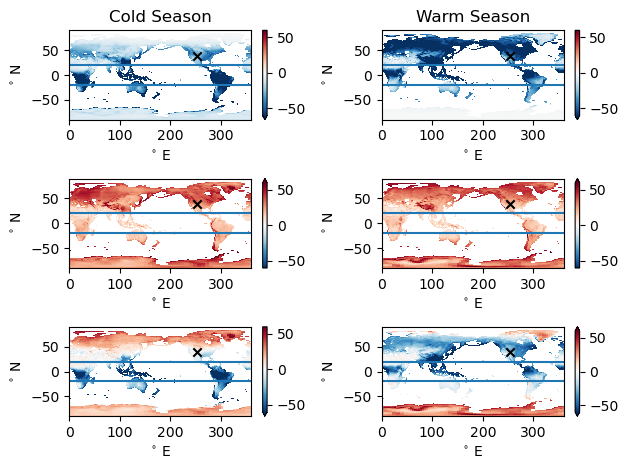

In [19]:
fig,ax=plt.subplots(3,2)

cold_season_crf_sw.where(sfc_elev_mon>.1).plot(ax=ax[0,0], vmin=-60, vmax=60, cmap='RdBu_r')
warm_season_crf_sw.where(sfc_elev_mon>.1).plot(ax=ax[0,1], vmin=-60, vmax=60, cmap='RdBu_r')


cold_season_crf_lw.where(sfc_elev_mon>.1).plot(ax=ax[1,0], vmin=-60, vmax=60, cmap='RdBu_r')
warm_season_crf_lw.where(sfc_elev_mon>.1).plot(ax=ax[1,1], vmin=-60, vmax=60, cmap='RdBu_r')


cold_season_crf_net.where(sfc_elev_mon>.1).plot(ax=ax[2,0], vmin=-60, vmax=60, cmap='RdBu_r')
warm_season_crf_net.where(sfc_elev_mon>.1).plot(ax=ax[2,1], vmin=-60, vmax=60, cmap='RdBu_r')




for axx in ax.flatten():
    axx.axhline(20)
    axx.axhline(-20)
    axx.scatter(360 -107, 39.3, marker='x', color='black')
    #xxx.scatter(360 -107, 39.3)
    # axx.set_ylim(25,60)
    # axx.set_xlim(220,300)
    axx.set_xlabel("$^{\circ}$ E")
    axx.set_ylabel("$^{\circ}$ N")
    axx.set_title("")

ax[0,0].set_title("Cold Season")
ax[0,1].set_title("Warm Season")


plt.tight_layout()

/tmp/ipykernel_1220087/1788866055.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  axx.set_xticklabels(360 - axx.get_xticks() )


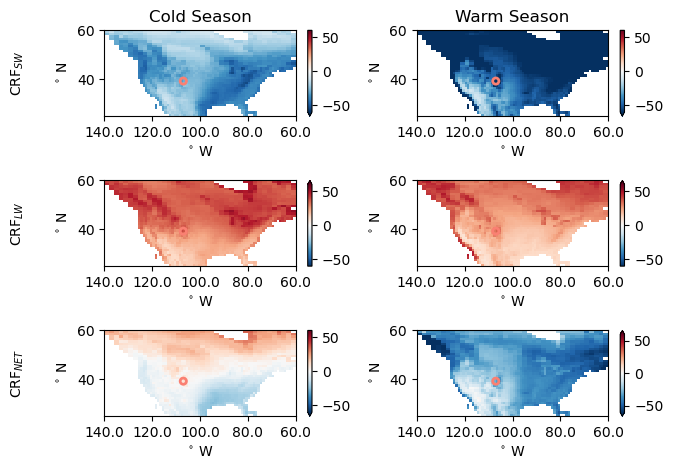

In [20]:
fig,ax=plt.subplots(3,2)

cold_season_crf_sw.where(sfc_elev_mon>.1).plot(ax=ax[0,0], vmin=-60, vmax=60, cmap='RdBu_r')
warm_season_crf_sw.where(sfc_elev_mon>.1).plot(ax=ax[0,1], vmin=-60, vmax=60, cmap='RdBu_r')


cold_season_crf_lw.where(sfc_elev_mon>.1).plot(ax=ax[1,0], vmin=-60, vmax=60, cmap='RdBu_r')
warm_season_crf_lw.where(sfc_elev_mon>.1).plot(ax=ax[1,1], vmin=-60, vmax=60, cmap='RdBu_r')


cold_season_crf_net.where(sfc_elev_mon>.1).plot(ax=ax[2,0], vmin=-60, vmax=60, cmap='RdBu_r')
warm_season_crf_net.where(sfc_elev_mon>.1).plot(ax=ax[2,1], vmin=-60, vmax=60, cmap='RdBu_r')




for axx in ax.flatten():
    axx.axhline(20)
    axx.axhline(-20)
    axx.scatter(360 - 107  , 39.3, facecolor='None', marker='o', edgecolor='salmon', s=20, zorder=10,  linewidth=2)
    axx.set_ylim(25,60)
    axx.set_xlim(220,300)
    axx.set_xlabel("$^{\circ}$ W")
    axx.set_ylabel("$^{\circ}$ N")
    axx.set_title("")
    axx.set_xticklabels(360 - axx.get_xticks() )

ax[0,0].set_title("Cold Season")
ax[0,1].set_title("Warm Season")


plt.tight_layout()

ax[0,0].text(-.45, .5, "CRF$_{SW}$", transform=ax[0,0].transAxes,  rotation=90, va='center', ha='center')
ax[1,0].text(-.45, .5, "CRF$_{LW}$", transform=ax[1,0].transAxes,  rotation=90, va='center', ha='center')
ax[2,0].text(-.45, .5, "CRF$_{NET}$", transform=ax[2,0].transAxes, rotation=90, va='center', ha='center')


plt.savefig("/global/homes/r/rudisill/gshare2/will_data/cre_project_images/Supp_FigureX_ceres_conus", dpi=300,  bbox_inches="tight")


In [21]:
lon,lat = np.meshgrid(cds.lon, cds.lat)

In [22]:
subset_crf_net = crf_net#.where((crf_net_mean.lat > 20) & (crf_net_mean.lat < 60)).where((crf_net_mean.lon > 200) & (crf_net_mean.lon < 300))


In [23]:
subset_crf_net

<xarray.DataArray (time: 8675, lat: 180, lon: 360)>
dask.array<add, shape=(8675, 180, 360), dtype=float32, chunksize=(563, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2000-03-01T12:00:00 ... 2023-11-30T12:00:00
  * lon      (lon) float32 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5

In [24]:
crf_doy = subset_crf_net.groupby(subset_crf_net.time.dt.dayofyear).mean().load()

In [25]:
def return_date_closest_to_zero(ds):
    if ds.min() > 0:  # we are never cooling the surface 
        return 9999
    if ds.max() < 0:   # we are never warming the surface 
        return -9999
    doy = np.argmax(ds < 0)
    if doy > 330:
        return 365 - doy   # this is because we are using Jan 1 through 
    return doy

In [26]:
def return_num_over_zero(ds):
    if ds.min() > 0:  # we are never cooling the surface 
        return 9999
    if ds.max() < 0:   # we are never warming the surface 
        return -9999
    num_over_zero = len(ds[np.where(ds > 5)])
    return num_over_zero


In [27]:
test = xr.apply_ufunc(return_date_closest_to_zero, 
                      crf_doy,
                      input_core_dims=[['dayofyear']],
                      vectorize=True)

In [28]:
days_with_warming = xr.apply_ufunc(return_num_over_zero, 
                      crf_doy,
                      input_core_dims=[['dayofyear']],
                      vectorize=True)

In [29]:
albedo_mean = albedo.mean(dim='time').compute()

/global/homes/r/rudisill/miniconda3/envs/xenv/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [30]:
jfm_alb = albedo[albedo.time.dt.month.isin([1,2,3])].mean(dim='time')

/tmp/ipykernel_1220087/806501072.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(360 - ax.get_xticks() )
/global/homes/r/rudisill/miniconda3/envs/xenv/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/global/homes/r/rudisill/miniconda3/envs/xenv/lib/python3.9/site-packages/xarray/plot/dataarray_plot.py:2021: UserWarning: The following kwargs were not used by contour: 'linestyle'
  primitive = ax.contour(x, y, z, **kwargs)


Text(0, 0.5, '$^{\\circ}$ N')

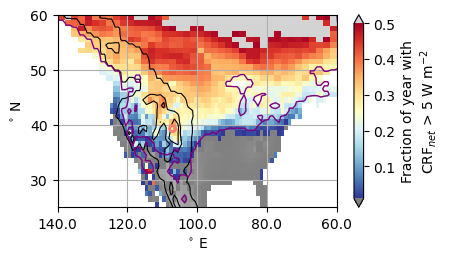

In [31]:
fig,ax=plt.subplots(figsize=(4.5,2.5))
ax.axhline(20)
ax.axhline(-20)
ax.scatter(360 -107, 39.3, marker='x', color='black')

##############
cmap = plt.get_cmap('RdYlBu_r')
cmap.set_under('gray')
cmap.set_over('lightgray')


sfc_elev_mon.where(ocean<80).plot(add_colorbar=False, cmap='gray')
leg=(days_with_warming.where(days_with_warming>0).where(ocean<80)/365).plot(ax=ax, vmin=.01, vmax=.5, cmap=cmap)
sfc_elev_mon.plot.contour(levels=[1000, 2000, 2500], ax=ax, colors=['black'], linewidths=.8)


ax.set_ylim(25,60)
ax.set_xlim(220,300)
ax.grid()
ax.set_title("CERES SYN1deg Ed. 4a")
leg.colorbar.set_label("Fraction of year with\n"+ "CRF$_{net}$ > 5 W m$^{-2}$")
ax.scatter(360 - 107  , 39.3, facecolor='None', marker='o', edgecolor='salmon', s=20, zorder=10,  linewidth=2)
ax.set_xticklabels(360 - ax.get_xticks() )
jfm_alb.plot.contour(ax=ax, levels=[.2], colors='purple', linewidths=1, linestyle='--')
ax.set_xlabel("$^{\circ}$ E")
ax.set_ylabel("$^{\circ}$ N")

#plt.savefig("/global/homes/r/rudisill/gshare2/will_data/cre_project_images/Figure_X_CERES_positive_crf", dpi=300, bbox_inches="tight")


In [32]:
# fig,ax=plt.subplots()
# (test.sel(lat=39.5)/365).where(ocean.sel(lat=39.5)<78).plot(ax=ax)

# ax2=ax.twinx()
# sfc_elev_mon.sel(lat=39.5).where(ocean.sel(lat=39.5)<78).plot(ax=ax2, color='red')

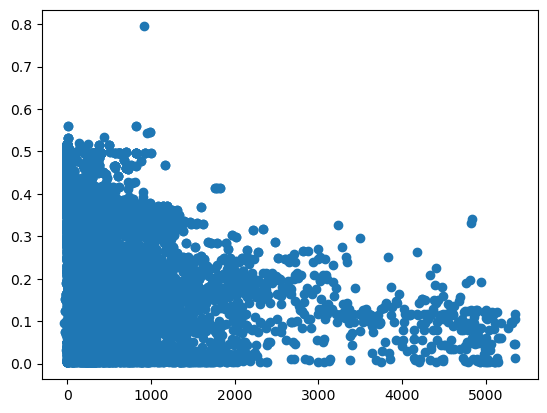

In [33]:
plt.scatter(sfc_elev_mon, test.where(test>0).where(test<500).where(ocean<78)/365)

(200.0, 300.0)

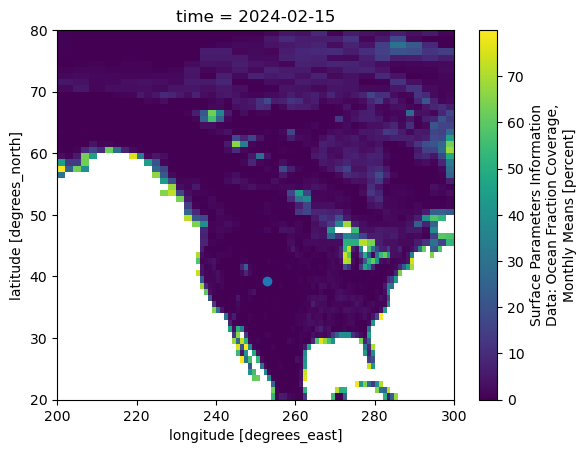

In [34]:
fig,ax=plt.subplots()
ocean.where(ocean<80).plot(ax=ax)
ax.scatter(360 -107, 39.3)
ax.set_ylim(20,80)
ax.set_xlim(200,300)

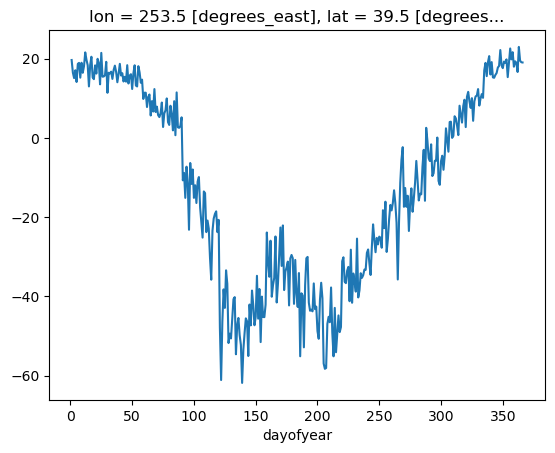

In [35]:
crf_doy.sel(lat=39.01, lon=(360-107.0), method='nearest').plot()

In [36]:
# fig,ax=plt.subplots()
# x  = sfc_elev_mon.values.flatten()
# y  = (crf_lw.mean(dim='time')/cds.cldarea_total_daily.mean(dim='time')).values.flatten()
# cb = ax.scatter(x, y, c=lat.flatten())
# fig.colorbar(cb)


In [37]:
# fig,ax=plt.subplots()
# x=sfc_elev_mon.values.flatten()
# y=(cre_sw.mean(dim='time')/cds.cldarea_total_daily.mean(dim='time')).values.flatten()
# cb=ax.scatter(x, y, c=lat.flatten())
# fig.colorbar(cb)




In [38]:
crf_single_point = crf_net.sel(lat=39.01, lon=(360-107.0), method='nearest')

In [39]:
albedo_single_point = albedo.sel(lat=39.01, lon=(360-107.0), method='nearest')

In [40]:
cld_single_point = cds.cldarea_total_daily.sel(lat=39.01, lon=(360-107.0), method='nearest')

In [41]:
crfdoy = crf_single_point.groupby(crf_single_point.time.dt.dayofyear).mean().compute()
albdoy = albedo_single_point.groupby(crf_single_point.time.dt.dayofyear).mean().compute()
clddoy = cld_single_point.groupby(crf_single_point.time.dt.dayofyear).mean().compute()

/global/homes/r/rudisill/miniconda3/envs/xenv/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [42]:
### look at the SAIL obs...
master_df = pd.read_csv("/global/homes/r/rudisill/gshare2/will_data/crf_files/master_df_sail_cre.csv", index_col=0, parse_dates=True)                        

In [43]:
kolias = xr.open_dataset("/global/homes/r/rudisill/gshare/sail_data_will/data_store_sail_period/kollias/cbh_kolias2.nc").to_pandas()
cloud_present_kolias = kolias.copy()
cloud_present_kolias[cloud_present_kolias == -1] = 0
cloud_present_kolias[cloud_present_kolias > 0] = 1


kolias_lt_4000 = kolias.where(kolias < 6000)
kolias_lt_4000.fillna(-1, inplace=True)
cloud_present_kolias_lt_4000 = kolias_lt_4000.copy()
cloud_present_kolias_lt_4000[cloud_present_kolias_lt_4000 == -1] = 0
cloud_present_kolias_lt_4000[cloud_present_kolias_lt_4000 > 0] = 1

master_df['cloud_present'] = cloud_present_kolias_lt_4000.resample("1h").mean().reindex(master_df.index) * 100

In [44]:
cre_sw_obs  = (master_df.qcrad_swd - master_df.rrtmg_swd_clear).where(master_df.shadow<.3).fillna(0)
cre_lw_obs  = (master_df.qcrad_lwd - master_df.rrtmg_lwd_clear)
crf_sw_obs  = (cre_sw_obs * (1-master_df.albedo))
crf_lw_obs  = cre_lw_obs + (master_df.ml_lwu_clear - master_df.qcrad_lwu)
crf_net_obs = crf_sw_obs + crf_lw_obs

In [45]:
crfdoystd = crf_single_point.groupby(crf_single_point.time.dt.dayofyear).std().compute()

In [46]:
ceres_crf_sail_period = crf_single_point.sel(time=slice('2021-09-01', '2023-06-15'))

In [47]:
ceres_crf_sail_period = ceres_crf_sail_period.groupby(ceres_crf_sail_period.time.dt.dayofyear).mean()

In [48]:
def resamp_midpoint(df, freq):
    dlist = []
    mnlist = []
    for gp in df.resample(freq):
        midpoint = pd.Interval(gp[-1].index[0], gp[-1].index[-1]).mid
        dlist.append(midpoint)
        mnlist.append(gp[-1].mean())
    return pd.Series(mnlist, index=dlist)

In [49]:
clddoy = clddoy/100

In [50]:
obs_clddoy = (master_df['cloud_present']/100).groupby(master_df.index.dayofyear).mean()

In [51]:
obs_cld = (master_df['cloud_present']/100).resample("1d").mean()

In [52]:
ceres_cld = cld_single_point.to_pandas().resample("1d").mean()

(-100.0, 50.0)

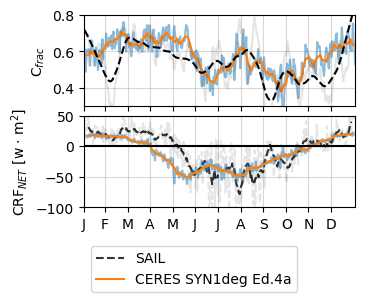

In [53]:
fig,axx = plt.subplots(2,1, figsize=(3.5, 2.5), gridspec_kw={'height_ratios': [1,1]})

ax = axx[0]
### top plot 
#(albdoy * 100).plot(ax=ax, color='red', label='albedo')

clddoy.plot(ax=ax, alpha=0.5)
clddoy.rolling(dayofyear=10, center=True).mean().bfill(dim='dayofyear').ffill(dim='dayofyear').plot(ax=ax)

#obs_clddoy.plot(ax=ax, label=None, alpha=.05, color='black')
obs10day = obs_clddoy.rolling(10, center=True).mean()

ax.plot(obs10day, label='rolling mean', alpha=.1, color='black')
smoothed_values = lowess(obs_clddoy, obs_clddoy.index, frac=0.12)  # frac determines the amount of smoothing
ax.plot(obs_clddoy.index, smoothed_values[:, 1], color='black', linestyle='--', label='LOESS filter')
#ax.legend()




#ax.legend(loc='lower left')
ax.set_ylabel("%")
#ax.plot(range(0, 366), albedo_single_point.sel(time=slice('2021-01-01', '2022-01-01')).values*100, color='pink', linestyle='--')
#ax.plot(range(0, 366), albedo_single_point.sel(time=slice('2022-01-01', '2023-01-01')).values*100, color='purple', linestyle='-.')

### crf plot 


crf_net_obs.groupby(crf_net_obs.index.dayofyear).mean().plot(ax=axx[1], alpha=.1, color='black', linestyle='--')
crf_net_obs.groupby(crf_net_obs.index.dayofyear).mean().rolling(10, center=True).mean().plot(ax=axx[1], alpha=.8, color='black', linestyle='--',  label='SAIL')



## CERES
crfdoy.plot(ax=axx[1],alpha=.5)
crfdoy.rolling(dayofyear=10, center=True).mean().plot(ax=axx[1], label="CERES SYN1deg Ed.4a")


axx[1].axhline(0, color='black')
leg=axx[1].legend(loc='lower left', bbox_to_anchor=(-0.0, -1.0))
#leg.set_title("Daily CRF NET")
#axx2 = axx[1].twinx()
#crfdoystd.plot(ax=axx2, color='red')


month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
days_in_month = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]) 

for axxx in [axx[0], axx[1]]:
   axxx.set_xticks(np.cumsum(days_in_month) - 31) #- days_in_month/2)
   axxx.set_xticklabels(month_names)

axx[0].set_xlabel('')
fig.subplots_adjust(hspace=0.1)
axx[1].set_title("")
#axx[0].fill_between([90, 150], 60, alpha=.1)
#axx[1].fill_between([90, 150], 60,  alpha=.1)

axx[0].grid(alpha=.5)
axx[1].grid(alpha=.5)
axx[0].set_xticklabels("")
axx[1].set_ylabel(r"CRF$_{NET}$ [w $\cdot$ m$^2$]")
#axx[0].set_title("CERES_SYN1deg_Ed4A \n 39.01N, 107.0W, 2000-2023 Avg.")
axx[0].set_title("")




for axz in axx.flatten():
   axz.set_xlim(0,366)

axx[0].set_ylabel("C$_{frac}$")
axx[0].set_ylim(.3,.8)
axx[1].set_ylim(-159, 70)
axx[1].set_xlabel("")
axx[1].set_ylim(-100, 50)





#plt.savefig("/global/homes/r/rudisill/gshare2/will_data/cre_project_images/FigureX_crf_ceres_v_sail", dpi=300,  bbox_inches="tight")



In [54]:
foo=1

#### combine the CERES map with the SAIL timeseries

/tmp/ipykernel_1220087/1214297015.py:115: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(360 - ax1.get_xticks() )
/global/homes/r/rudisill/miniconda3/envs/xenv/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/global/homes/r/rudisill/miniconda3/envs/xenv/lib/python3.9/site-packages/xarray/plot/dataarray_plot.py:2021: UserWarning: The following kwargs were not used by contour: 'linestyle'
  primitive = ax.contour(x, y, z, **kwargs)


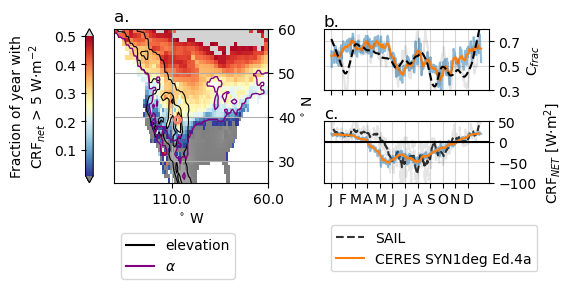

In [55]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create a figure
fig = plt.figure(figsize=(5.5, 2.))

# Create a GridSpec with 2 rows and 2 columns
gs = gridspec.GridSpec(2, 2, width_ratios=[1, .8], height_ratios=[1, 1])

# Add a subplot that spans the first column (both rows)
ax1 = plt.subplot(gs[:, 0])  # spans all rows in the first column

# Add a subplot to the top right
ax2 = plt.subplot(gs[0, 1])  # top right plot

# Add a subplot to the bottom right
ax3 = plt.subplot(gs[1, 1])  # bottom right plot


#######################
###### PLOT THE CURVES 
########################

### top plot 
#(albdoy * 100).plot(ax=ax, color='red', label='albedo')

clddoy.plot(ax=ax2, alpha=0.5)
clddoy.rolling(dayofyear=10, center=True).mean().bfill(dim='dayofyear').ffill(dim='dayofyear').plot(ax=ax2)

#obs_clddoy.plot(ax=ax, label=None, alpha=.05, color='black')
obs10day = obs_clddoy.rolling(10, center=True).mean()

ax2.plot(obs10day, label='rolling mean', alpha=.1, color='black')
smoothed_values = lowess(obs_clddoy, obs_clddoy.index, frac=0.12)  # frac determines the amount of smoothing
ax2.plot(obs_clddoy.index, smoothed_values[:, 1], color='black', linestyle='--', label='LOESS filter')
#ax.legend()




#ax.legend(loc='lower left')
ax2.set_ylabel("%")
#ax.plot(range(0, 366), albedo_single_point.sel(time=slice('2021-01-01', '2022-01-01')).values*100, color='pink', linestyle='--')
#ax.plot(range(0, 366), albedo_single_point.sel(time=slice('2022-01-01', '2023-01-01')).values*100, color='purple', linestyle='-.')

### crf plot 


crf_net_obs.groupby(crf_net_obs.index.dayofyear).mean().plot(ax=ax3, alpha=.1, color='black', linestyle='--')
crf_net_obs.groupby(crf_net_obs.index.dayofyear).mean().rolling(10, center=True).mean().plot(ax=ax3, alpha=.8, color='black', linestyle='--',  label='SAIL')

## CERES
crfdoy.plot(ax=ax3,alpha=.5)
crfdoy.rolling(dayofyear=10, center=True).mean().plot(ax=ax3, label="CERES SYN1deg Ed.4a")


ax3.axhline(0, color='black')


month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
days_in_month = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]) 

for axxx in [ax3, ax2]:
    axxx.set_xticks(np.cumsum(days_in_month) - 31) #- days_in_month/2)
    axxx.set_xticklabels(month_names)
    axxx.grid(alpha=.5)
    axxx.grid(alpha=.5)
    axxx.set_title("")
    axxx.yaxis.tick_right()
    axxx.yaxis.set_label_position("right")

ax2.set_xlabel('')
ax2.set_title("")
ax2.set_xticklabels([])

ax2.set_ylabel("C$_{frac}$")
ax3.set_ylabel("CRF$_{NET}$ [W$\cdot$m$^2$]")

ax2.set_ylim(.3,.8)
ax3.set_ylim(-159, 70)
ax3.set_xlabel("")
ax3.set_ylim(-100, 50)
ax3.set_yticks([-100, -50, 0, 50])
ax2.set_yticks([.3, .5, .7])

ax3.legend(loc='lower left', bbox_to_anchor=(0.0, -1.55))


########################
### NOW PLOT MORE STUFF
########################

ax1.axhline(20)
ax1.axhline(-20)
ax1.scatter(360 -107, 39.3, marker='x', color='black')

##############
cmap = plt.get_cmap('RdYlBu_r')
cmap.set_under('gray')
cmap.set_over('lightgray')


sfc_elev_mon.where(ocean<80).plot(add_colorbar=False, cmap='gray', ax=ax1)
leg=(days_with_warming.where(days_with_warming>0).where(ocean<80)/365).plot(ax=ax1, vmin=.01, vmax=.5, cmap=cmap, cbar_kwargs={"location": "left"})

sfc_elev_mon.plot.contour(levels=[1000, 2000, 2500], ax=ax1, colors=['black'], linewidths=.8)


ax1.set_ylim(25,60)
ax1.set_xlim(220,300)
ax1.grid()
ax1.set_title("CERES SYN1deg Ed. 4a")
leg.colorbar.set_label("Fraction of year with\n"+ "CRF$_{net}$ > 5 W$\cdot$m$^{-2}$")
ax1.scatter(360 - 107  , 39.3, facecolor='None', marker='o', edgecolor='salmon', s=20, zorder=10,  linewidth=2)
ax1.set_xticklabels(360 - ax1.get_xticks() )
jfm_alb.plot.contour(ax=ax1, levels=[.2], colors='purple', linewidths=1, linestyle='--')
ax1.set_xlabel("$^{\circ}$ W")
ax1.set_ylabel("$^{\circ}$ N")
ax1.yaxis.tick_right()
ax1.yaxis.set_label_position("right")


from matplotlib.lines import Line2D
legend_handles = [Line2D([0], [0], color='black',lw=1.5,  label='elevation'),
                  Line2D([0], [0], color='purple', lw=1.5, label=r'$\alpha$')]

# Add legend to the plot
ax1.legend(handles=legend_handles, loc='lower left', bbox_to_anchor=(0.0, -.67))


plt.subplots_adjust(wspace=.3, hspace=.5)


ax1.text(0.0, 1.05, "a.", transform=ax1.transAxes, fontsize=12)
ax2.text(0.0, 1.05, "b.", transform=ax2.transAxes, fontsize=12)
ax3.text(0.0, 1.05, "c.", transform=ax3.transAxes, fontsize=12)

plt.savefig("/global/homes/r/rudisill/gshare2/will_data/cre_project_images/FigureX_crf_ceres_v_sail", dpi=300,  bbox_inches="tight")


In [56]:

from matplotlib.collections import LineCollection
import warnings 
def colored_line_between_pts(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified between (x, y) points by a third value.

    It does this by creating a collection of line segments between each pair of
    neighboring points. The color of each segment is determined by the
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should have a size one less than that of x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Check color array size (LineCollection still works, but values are unused)
    if len(c) != len(x) - 1:
        warnings.warn(
            "The c argument should have a length one less than the length of x and y. "
            "If it has the same length, use the colored_line function instead."
        )

    # Create a set of line segments so that we can color them individually
    # This creates the points as an N x 1 x 2 array so that we can stack points
    # together easily to get the segments. The segments array for line collection
    # needs to be (numlines) x (points per line) x 2 (for x and y)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, **lc_kwargs)

    # Set the values used for colormapping
    lc.set_array(c)

    return ax.add_collection(lc)


# # -------------- Create and show plot --------------
# x = np.linspace(0, 3 * np.pi, 500)
# y = np.sin(x)
# dydx = np.cos(0.5 * (x[:-1] + x[1:]))  # first derivative

# fig2, ax2 = plt.subplots()
# line = colored_line_between_pts(x, y, dydx, ax2, linewidth=2, cmap="viridis")
# fig2.colorbar(line, ax=ax2, label="dy/dx")

# ax2.set_xlim(x.min(), x.max())
# ax2.set_ylim(-1.1, 1.1)
# ax2.set_title("Color between points")

# plt.show()

In [57]:
ceres_crf_net = subset_crf_net.sel(lat=39.0, lon=(360-107.0), method='nearest').to_pandas()

In [58]:
ceres_crf_net_1d = ceres_crf_net.resample("1d").mean().loc[crf_net_obs.resample("1d").mean().index]

In [59]:
ceres_crf_doy = ceres_crf_net.groupby(ceres_crf_net.index.dayofyear).mean()
ceres_cfrac_doy = cld_single_point.to_pandas().groupby(cld_single_point.to_pandas().index.dayofyear).mean() 

In [60]:
ceres_cld = cld_single_point.to_pandas().resample("1d").mean()

In [61]:
dr = pd.date_range("2021-01-01", "2024-01-01", freq='1d')

def doy_avg_to_dr(dr, doydata):
    mapped_data = pd.DataFrame({
        'datetime': dr,
        'day_of_year': dr.dayofyear})  # Extract DOY from the datetime

    mapped_data['data'] = mapped_data['day_of_year'].map(doydata)  # Map DOY values
    return mapped_data.data


In [62]:
doyclimo = doy_avg_to_dr(dr, ceres_crf_doy)

In [63]:
doyclimo_cld = doy_avg_to_dr(dr, ceres_cfrac_doy)

In [64]:
lo_doyclimo_cld = lowess(doyclimo_cld, doyclimo_cld.index, frac=0.05)  # frac determines the amount of smoothing


In [65]:
lo_doyclimo_crf = lowess(doyclimo, doyclimo.index, frac=0.05)  # frac determines the amount of smoothing


In [66]:
lodf = pd.DataFrame(data={"lo_crf":lo_doyclimo_crf[:, 1], 
                          "lo_cfrac":lo_doyclimo_cld[:,1],
                          "crf":doyclimo.values,
                          "cfrac":doyclimo_cld.values}, index=dr)

In [67]:
sail_period = pd.date_range("2021-09-01", "2023-06-15", freq='1d')

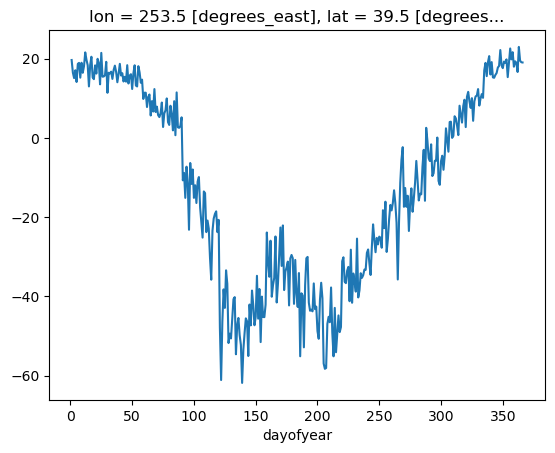

In [68]:
crfdoy.plot()

/tmp/ipykernel_1220087/3299590087.py:52: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax1.scatter(
/global/homes/r/rudisill/miniconda3/envs/xenv/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/global/homes/r/rudisill/miniconda3/envs/xenv/lib/python3.9/site-packages/xarray/plot/dataarray_plot.py:2021: UserWarning: The following kwargs were not used by contour: 'linestyle'
  primitive = ax.contour(x, y, z, **kwargs)
/tmp/ipykernel_1220087/3299590087.py:66: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(360 - ax1.get_xticks() )


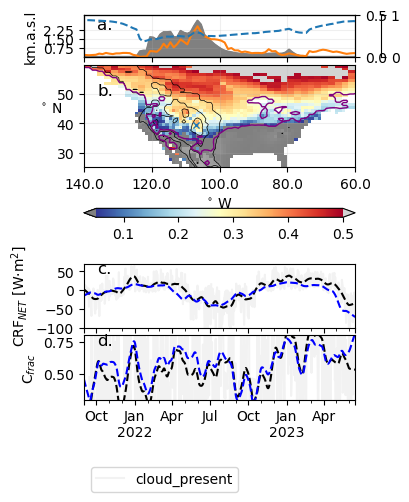

In [69]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator

# ===============================
# Create Figure and Grid Layout
# ===============================
fig = plt.figure(figsize=(3.5, 5.))
gs = gridspec.GridSpec(
    7, 2, 
    width_ratios=[1, 1], 
    height_ratios=[0.33, 0.8, 0.2, 0.07, 0.24, 0.5, 0.5]
)

# Define subplots using the grid specification
ax4 = plt.subplot(gs[0, :])  # Top row subplot
ax1 = plt.subplot(gs[1, :])  # Large map subplot
axsp1 = plt.subplot(gs[2, :])  # Spacer
cbaxsp2 = plt.subplot(gs[3, :])  # Colorbar space
axsp3 = plt.subplot(gs[4, :])  # Spacer
ax2 = plt.subplot(gs[5, :])  # Middle plot (curve 1)
ax3 = plt.subplot(gs[6, :])  # Bottom plot (curve 2)

# Hide unused spacer subplots
axsp1.set_visible(False)
axsp3.set_visible(False)

# ===============================
# Plot Data: Map (ax1)
# ===============================
# Configure colormap
cmap = plt.get_cmap('RdYlBu_r')
cmap.set_under('gray')
cmap.set_over('lightgray')
norm = Normalize(vmin=0.05, vmax=0.5)

# Plot base map and overlays
sfc_elev_mon.where(ocean < 80).plot(
    add_colorbar=False, cmap='gray', ax=ax1
)

leg = (days_with_warming.where(days_with_warming > 0).where(ocean < 80) / 365).plot(
    ax=ax1, vmin=0.05, vmax=0.5, cmap=cmap, add_colorbar=True,
    cbar_kwargs={"cax": cbaxsp2, 'orientation': 'horizontal'}
)

sfc_elev_mon.plot.contour(levels=[750, 1500, 2250], ax=ax1, colors=['black'], linewidths=0.5)

# Map customizations
ax1.scatter(
    360 - 107, 39.3, marker='x', edgecolor='black', s=20, zorder=10, linewidth=1
)
jfm_alb.plot.contour(
    ax=ax1, levels=[0.2], colors='purple', linewidths=1, linestyle='--')

ax1.set_xlabel("$^{\circ}$ W")
ax1.set_ylabel("$^{\circ}$ N", rotation=0)
ax1.set_yticks([30, 40, 50])

ax1.set_ylim(25, 60)
ax1.set_xlim(220, 300)
ax1.grid(alpha=0.2)
ax1.set_title("")
ax1.set_xticklabels(360 - ax1.get_xticks() )


# ===============================
# Plot Data: Curves (ax2, ax3)
# ===============================
# Rolling mean plots

# plot ... more the obs 
crf_net_obs.resample("1d").mean().plot(ax=ax2, color='gray', alpha=.1)
obs_cld.resample("1d").mean().plot(ax=ax3, color='gray', alpha=.1)

# make smoothed lines for the obs ....
lo_obscrf = lowess(crf_net_obs.resample("1d").mean(), crf_net_obs.resample("1d").mean().index, frac=0.05)
lo_obscld = lowess(obs_cld, obs_cld.index, frac=0.05)

# plot the smoothed lines for the obs 
ax2.plot(crf_net_obs.resample("1d").mean().dropna().index, lo_obscrf[:, 1], color='black', linestyle='--')
ax3.plot(obs_cld.dropna().index, lo_obscld[:, 1], color='black', linestyle='--')

# plot CERES 
#(lodf.lo_cfrac/100).loc[sail_period].plot(ax=ax3)
#lodf.lo_crf.loc[sail_period].plot(ax=ax2)


# Plot CERES data
ceres_cld_lowess = lowess(ceres_cld.loc[sail_period], ceres_cld.loc[sail_period].index, frac=0.05)

ceres_crf_sail = ceres_crf_net.resample("1d").mean()
ceres_crf_lowess_sail = lowess(ceres_crf_sail.loc[sail_period], ceres_crf_sail.loc[sail_period].index, frac=0.05)

ax2.plot(ceres_crf_sail.loc[sail_period].index, ceres_crf_lowess_sail[:,1], color='blue', linestyle='--')
ax3.plot(ceres_cld.loc[sail_period].index, ceres_cld_lowess[:,1]/100, color='blue', linestyle='--')



# Customize ax2
ax2.set_ylabel("CRF$_{NET}$ [W$\cdot$m$^2$]")
ax2.set_xticklabels([])  # Remove x-tick labels
ax2.set_title("")        # Remove title
ax2.set_ylim(-75, 70)
ax2.set_yticks([-100, -50, 0, 50])


# Customize ax3
ax3.set_ylabel("C$_{frac}$")
ax3.set_xlabel("")       # Remove x-label
ax3.legend(loc='lower left', bbox_to_anchor=(0.0, -1.55))
ax3.set_ylim(0.3, 0.8)


# ===============================
# Top Axis (ax4) and Twin Axes
# ===============================
# Primary axis (elevation)
dat = sfc_elev_mon.sel(lat=39.0, method='nearest')
ax4.plot(360 - dat.lon, dat.values / 1000, color='gray')
ax4.fill_between(360 - dat.lon, 0, dat.values / 1000, color='gray')
ax4.grid(alpha=0.2)
ax4.set_ylim(0, 3.5)
ax4.set_xlim(140, 60)
ax4.set_ylabel("km.a.s.l")
ax4.set_xticklabels([])
ax4.set_yticks([.75, 1.5, 2.25])


# Twin axes for additional data
ax41 = ax4.twinx()
ax42 = ax4.twinx()
ax42.spines.right.set_position(("axes", 1.095))

# Plot on twin axes
ydat = (days_with_warming.sel(lat=39.0, method='nearest') / 365).values
#colored_line_between_pts(360 - dat.lon, ydat, ydat, ax41, linewidth=2, cmap=cmap, norm=norm)
ax41.plot(360 - dat.lon, ydat, color='tab:orange')
ax42.plot(
    360 - dat.lon, avg_cloud.sel(lat=39.0, method='nearest') / 100,
    color='tab:blue', linestyle='--'
)

# Customize twin axes
ax41.set_ylim(0, 0.5)
ax42.set_ylim(0, 1.0)
ax41.yaxis.label.set_color('red')
ax42.yaxis.label.set_color('blue')

# Add minor ticks


# ===============================
# Add Text Annotations
# ===============================
ax4.text(0.05, 0.65, "a.", transform=ax4.transAxes, fontsize=12)
ax1.text(0.05, 0.70, "b.", transform=ax1.transAxes, fontsize=12)
ax2.text(0.05, 0.85, "c.", transform=ax2.transAxes, fontsize=12)
ax3.text(0.05, 0.85, "d.", transform=ax3.transAxes, fontsize=12)

# ===============================
# Adjust Layout and Save
# ===============================
fig.subplots_adjust(hspace=0.16, wspace=0.1)

# Uncomment to save the figure
# plt.savefig(
#     "/global/homes/r/rudisill/gshare2/will_data/cre_project_images/FigureX_crf_ceres_v_sail",
#     dpi=300, bbox_inches="tight"
# )

plt.show()



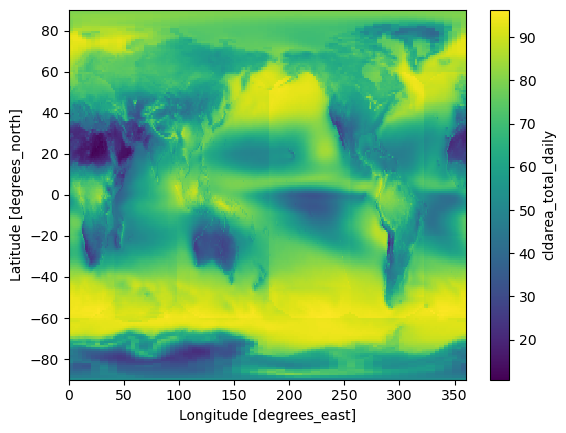

In [70]:
avg_cloud.plot()

In [73]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.ticker import AutoMinorLocator
from statsmodels.nonparametric.smoothers_lowess import lowess

# ===============================
# Data Preprocessing
# ===============================
# Resampling and averaging
crf_net_obs_resampled = crf_net_obs.resample("1d").mean()
obs_cld_resampled = obs_cld.resample("1d").mean()

# Lowess smoothing
lo_obscrf = lowess(crf_net_obs_resampled.dropna(), crf_net_obs_resampled.dropna().index, frac=0.035)
lo_obscld = lowess(obs_cld.dropna(), obs_cld.dropna().index, frac=0.035)

# Preprocess CERES data
ceres_cld_lowess = lowess(ceres_cld.loc[sail_period], ceres_cld.loc[sail_period].index, frac=0.035)
ceres_crf_lowess_sail = lowess(ceres_crf_sail.loc[sail_period], ceres_crf_sail.loc[sail_period].index, frac=0.035)

# Elevation and other variables
dat = sfc_elev_mon.sel(lat=39.0, method='nearest')
days_warming = (days_with_warming.sel(lat=39.0, method='nearest') / 365).values
avg_cloud = avg_cloud.sel(lat=39.0, method='nearest') / 100

# Masked data for the map
sfc_elev_masked = sfc_elev_mon.where(ocean < 80)
days_with_warming_masked = (days_with_warming.where(days_with_warming > 0).where(ocean < 80) / 365)


/tmp/ipykernel_1220087/1631353201.py:54: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels([int(x) for x in 360 - ax1.get_xticks()])


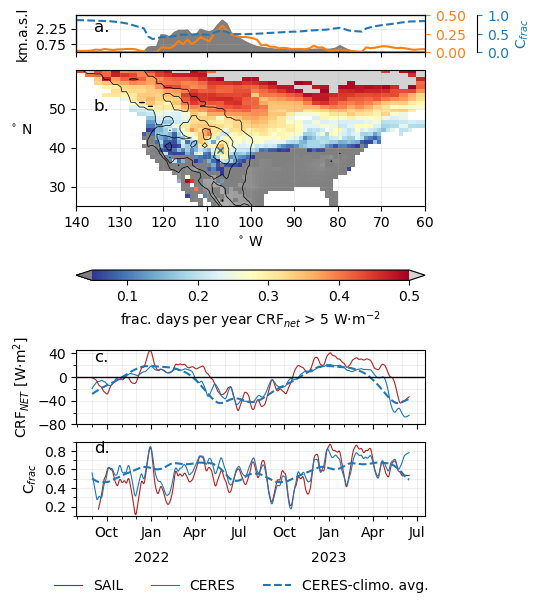

In [75]:
# ===============================
# Plotting
# ===============================
# Create Figure and Grid Layout
fig = plt.figure(figsize=(4.5, 6.5))
gs = gridspec.GridSpec(
    7, 2, 
    width_ratios=[1, 1], 
    height_ratios=[0.25, 0.92, 0.2, 0.07, 0.24, 0.5, 0.5]
)

# Define subplots
ax4 = plt.subplot(gs[0, :])  # Top row subplot
ax1 = plt.subplot(gs[1, :])  # Large map subplot
axsp1 = plt.subplot(gs[2, :])  # Spacer
cbaxsp2 = plt.subplot(gs[3, :])  # Colorbar space
axsp3 = plt.subplot(gs[4, :])  # Spacer
ax2 = plt.subplot(gs[5, :])  # Middle plot (curve 1)
ax3 = plt.subplot(gs[6, :])  # Bottom plot (curve 2)

# Hide unused spacer subplots
axsp1.set_visible(False)
axsp3.set_visible(False)

# Configure colormap
cmap = plt.get_cmap('RdYlBu_r')
cmap.set_under('gray')
cmap.set_over('lightgray')
norm = Normalize(vmin=0.05, vmax=0.5)

# ===============================
# Plot Map (ax1)
# ===============================
sfc_elev_masked.plot(add_colorbar=False, cmap='gray', ax=ax1)

leg = days_with_warming_masked.plot(
    ax=ax1, vmin=0.05, vmax=0.5, cmap=cmap, add_colorbar=True,
    cbar_kwargs={"cax": cbaxsp2, 'orientation': 'horizontal'}
)
leg.colorbar.set_label("frac. days per year CRF$_{net}$ > 5 W$\cdot$m$^{-2}$")

sfc_elev_mon.plot.contour(levels=[750, 1500, 2250], ax=ax1, colors=['black'], linewidths=0.5)

# Map customizations
ax1.scatter(360 - 107, 39.3, marker='x',  s=20, zorder=10, linewidth=1)
#jfm_alb.plot.contour(ax=ax1, levels=[0.2], colors='purple', linewidths=1, linestyle='--')
ax1.set_xlabel("$^{\circ}$ W")
ax1.set_ylabel("$^{\circ}$ N", rotation=0, labelpad=20)
ax1.set_yticks([30, 40, 50])
ax1.set_ylim(25, 60)
ax1.set_xlim(220, 300)
ax1.grid(alpha=0.2)
ax1.set_title("")
ax1.set_xticklabels([int(x) for x in 360 - ax1.get_xticks()]) 


# ===============================
# Plot Curves (ax2, ax3)
# ===============================
# Smoothed lines for observation
ax2.plot(crf_net_obs_resampled.dropna().index, lo_obscrf[:, 1], color='firebrick', linestyle='-', linewidth=.8)
ax3.plot(obs_cld.dropna().index, lo_obscld[:, 1], color='firebrick', linestyle='-', linewidth=.8, label='SAIL')

# Smoothed CERES data
ax2.plot(ceres_crf_sail.loc[sail_period].index, ceres_crf_lowess_sail[:, 1], color='tab:blue', linestyle='-', linewidth=.8)
ax3.plot(ceres_cld.loc[sail_period].index, ceres_cld_lowess[:, 1] / 100, color='tab:blue', linestyle='-', linewidth=.8, label='CERES')

#climo avg CERES data
ax2.plot(lodf.loc[sail_period].index, lodf.loc[sail_period].lo_crf,   color='tab:blue', linestyle='--')
ax3.plot(lodf.loc[sail_period].index, lodf.loc[sail_period].lo_cfrac/100., color='tab:blue', linestyle='--', label='CERES-climo. avg.')


# Customize ax2
ax2.set_ylabel("CRF$_{NET}$ [W$\cdot$m$^2$]")
ax2.set_xticklabels([])  # Remove x-tick labels
ax2.set_title("")        # Remove title
ax2.set_yticks([-80, -40, 0, 40])
ax2.set_yticks(np.arange(-100,60, 20), minor=True)
ax2.set_ylim(-80, 45)

# Customize ax3
ax3.set_ylabel("C$_{frac}$")
ax3.set_ylim(0.2, .9)
ax3.set_yticks([.2,.4,.6,.8])
ax3.set_yticks(np.arange(.1, 1, .1), minor=True)

# Add tick formatters
major_locator = mdates.MonthLocator(bymonth=[10, 1, 4, 7])
minor_locator = mdates.MonthLocator(bymonth=range(13))
major_formatter = mdates.DateFormatter('%b')
minor_formatter = mdates.DateFormatter('')

for axx in [ax2, ax3]:
    axx.xaxis.set_major_locator(major_locator)
    axx.xaxis.set_minor_locator(minor_locator)
    axx.xaxis.set_major_formatter(major_formatter)
    axx.xaxis.set_minor_formatter(minor_formatter)
    axx.grid(alpha=.2, which='minor')
    axx.grid(alpha=.2, which='major')


ax2.set_xticklabels([])
ax2.axhline(0, color='black', linewidth=1)

# ===============================
# Plot Top Axis (ax4) and Twin Axes
# ===============================
ax4.plot(360 - dat.lon, dat.values / 1000, color='gray')
ax4.fill_between(360 - dat.lon, 0, dat.values / 1000, color='gray')
ax4.grid(alpha=0.2)
ax4.set_ylim(0, 3.5)
ax4.set_xlim(140, 60)
ax4.set_ylabel("km.a.s.l")
ax4.set_xticklabels([])
ax4.set_yticks([.75, 2.25])

# Twin axes
ax41 = ax4.twinx()
ax42 = ax4.twinx()
ax42.spines.right.set_position(("axes", 1.15))

# Plot on twin axes
ax41.plot(360 - dat.lon, days_warming, color='tab:orange')
ax42.plot(360 - dat.lon, avg_cloud, color='tab:blue', linestyle='--')

# Customize twin axes
ax41.set_ylim(0, 0.5)
ax42.set_ylim(0, 1.0)


ax42.yaxis.label.set_color('tab:blue') 
ax41.yaxis.label.set_color('tab:orange')
ax42.tick_params(axis='y', colors='tab:blue')
ax41.tick_params(axis='y', colors='tab:orange')


ax42.set_ylabel(r"C$_{frac}$")
ax41.set_ylabel('')
ax42.set_yticks([0, 0.5, 1.0])
ax41.set_yticks([0, 0.25, 0.5])

# ===============================
# Add Annotations
# ===============================
ax4.text(0.05, 0.55, "a.", transform=ax4.transAxes, fontsize=12)
ax1.text(0.05, 0.70, "b.", transform=ax1.transAxes, fontsize=12)
ax2.text(0.05, 0.85, "c.", transform=ax2.transAxes, fontsize=12)
ax3.text(0.05, 0.85, "d.", transform=ax3.transAxes, fontsize=12)

# Adjust layout
fig.subplots_adjust(hspace=.3, wspace=0.1)

# Uncomment to save
# plt.savefig("FigureX_crf_ceres_v_sail.png", dpi=300, bbox_inches="tight")
ax3.text(pd.to_datetime("2022-01-01 00:00:00"), -.4, "2022", color='black', horizontalalignment='center')
ax3.text(pd.to_datetime("2023-01-01 00:00:00"), -.4, "2023", color='black', horizontalalignment='center')

ax3.legend(
    loc='lower left',               # Position the legend at the top-center of the bbox
    bbox_to_anchor=(-.1, -1.2),     # Anchor the legend to the center and move it below
    ncol=3,                         # Arrange legend items in 2 columns (optional)
    frameon=False                   # Remove the frame (optional)
)

plt.savefig(        
    "/global/homes/r/rudisill/gshare2/will_data/cre_project_images/FigureX_crf_ceres_v_sail",
    dpi=300, bbox_inches="tight"
)

In [ ]:
from matplotlib.ticker import FuncFormatter


In [ ]:
test=pd.DataFrame({"cfrac":obs_clddoy})

In [ ]:
crf_net_warm = crf_net.sel(time=crf_net.time.dt.month.isin([4,5,6,7,8,9])).mean(dim='time').compute()

In [ ]:
cre_net_cold = cre_net.sel(time=cre_net.time.dt.month.isin([10,11,12,1,2,3])).mean(dim='time').compute()
cre_net_warm = cre_net.sel(time=cre_net.time.dt.month.isin([4,5,6,7,8,9])).mean(dim='time').compute()   


In [ ]:
fig,ax=plt.subplots()
ax.contour(sfc_elev_mon.sel(lat=slice(20,65), lon=slice(200,270))[::-1], levels=[10, 750, 1500, 2250], colors='black')
ax.imshow(crf_net_warm.sel(lat=slice(20,65), lon=slice(200,270))[::-1], vmin=-100, vmax=100, cmap='RdBu_r')


In [ ]:
fig,ax=plt.subplots()
#ax.scatter(sfc_elev_mon.where(sfc_elev_mon > 0).where(crf_net_cold.lat>20), crf_net_cold.where(sfc_elev_mon > 0), s=1 )
ax.scatter(sfc_elev_mon.where(sfc_elev_mon > 0).where(crf_net_cold.lat>20).where(crf_net_cold.lat<65), crf_net_cold, s=1)
ax.scatter(sfc_elev_mon.where(sfc_elev_mon > 0).where(crf_net_cold.lat>20).where(crf_net_cold.lat<65), crf_net_warm, s=1)


ax.axhline(0, color='black')

y = crf_net_cold.sel(lat=39.1, lon=(360 - 106.9), method='nearest').values
x = sfc_elev_mon.sel(lat=39.1, lon=(360 - 106.9), method='nearest').values
ax.scatter(x,y, marker='d', color='purple', facecolors='none', s=100, label='UCRB')


In [ ]:
albdoy.plot()

In [ ]:
fig,ax=plt.subplots()
ax.scatter(sfc_elev_mon.where(sfc_elev_mon > 0).where(cre_net_warm.lat>0), cre_net_warm.where(sfc_elev_mon > 0).where(cre_net_warm.lat>0), s=1 )
ax.axhline(0, color='black')

In [ ]:
mean_cre_net = (cre_lw + cre_sw).mean(dim='time')

In [ ]:
coldlist = [12,1,2]
mean_cre_net_cold = cre_lw.where(cre_lw.time.dt.month.isin(coldlist)) + cre_sw.where(cre_lw.time.dt.month.isin(coldlist))

In [ ]:
mean_cre_net_cold.mean(dim='time').sel(lat=slice(20,60), lon=slice(200,300)).plot(vmin=-50, vmax=50, cmap='bwr')

In [ ]:
360 - 106

In [ ]:
plt.scatter(sfc_elev_mon.where(sfc_elev_mon > 0), cre_lw.mean(dim='time').where(sfc_elev_mon > 0), s=1 )

In [ ]:
cre_mdl_nh = cre_lw.sel(lat=slice(35,65))
hgt_mdl_nh = sfc_elev_mon.sel(lat=slice(35,65))
cre_mdl_nh = cre_mdl_nh.where(hgt_mdl_nh > 0).mean(dim='time').compute()
hgt_mdl_nh = hgt_mdl_nh.where(hgt_mdl_nh > 0)



cre_mdl_sh = cre_lw.sel(lat=slice(-65,-35))
hgt_mdl_sh = sfc_elev_mon.sel(lat=slice(-65,-35))
cre_mdl_sh = cre_mdl_sh.where(hgt_mdl_sh > 0).mean(dim='time').compute()
hgt_mdl_sh = hgt_mdl_sh.where(hgt_mdl_sh > 0)



In [ ]:
cresw_mdl_nh = cre_sw.sel(lat=slice(35,65)).where(hgt_mdl_nh > 0).mean(dim='time').compute()
cresw_mdl_sh = cre_sw.sel(lat=slice(-65,-35)).where(hgt_mdl_sh > 0).mean(dim='time').compute()


In [ ]:
fig,axx=plt.subplots(1,2, figsize=(10,5))

ax = axx[0]
ax2 = axx[1]
ax.grid(alpha=.5)
ax.scatter(hgt_mdl_nh, cre_mdl_nh, s=3, color='orange', label='Northern Hemisphere')
ax.scatter(hgt_mdl_sh, cre_mdl_sh, s=3, label='Southern Hemisphere')
ax.set_xlabel("Terrain Elevation (m)")
ax.set_ylabel(r"CRE LW $(W/m^2)$")

#### do the longwave 

# UCRB
y = cre_mdl_nh.sel(lat=39.102033, lon=(360 - 106.9), method='nearest').values
x = hgt_mdl_nh.sel(lat=39.102033, lon=(360 - 106.9), method='nearest').values
ax.scatter(x,y, marker='d', color='purple', facecolors='none', s=100, label='UCRB')

# SIERRA
y = cre_mdl_nh.sel(lat=39.3, lon=(360 -120.3342856971791), method='nearest').values
x = hgt_mdl_nh.sel(lat=39.3, lon=(360 -120.3342856971791), method='nearest').values
ax.scatter(x,y, marker='d', color='red', facecolors='none', s=100, label='SIERRA')

# cad rockies 
y = cre_mdl_nh.sel(lat=52.130532, lon=(360 -117.449), method='nearest').values
x = hgt_mdl_nh.sel(lat=52.130532, lon=(360 -117.449), method='nearest').values
ax.scatter(x,y, marker='d', color='black', facecolors='none', s=100, label='CAD ROCKIES')

# himalaya 
y = cre_mdl_nh.sel(lat=31.648090308169763, lon=(79.7252667275815), method='nearest').values
x = hgt_mdl_nh.sel(lat=31.648090308169763, lon=(79.7252667275815), method='nearest').values
ax.scatter(x,y, marker='d', color='brown', facecolors='none', s=100, label='TIBETAN PLATEAU')

fig.suptitle("Avg. Daily 2000-2023 $CRE_{x}$ vs. Terrain Elevation \n All Mid-Latitude (35-65N/S) Land Gridpoints")
ax.set_ylim(0,90)

######## NOW DO THE SHORTWAVE 
ax = axx[1]
ax.grid(alpha=.5)
ax.scatter(hgt_mdl_nh, cresw_mdl_nh, s=3, color='orange', label='Northern Hemisphere')
ax.scatter(hgt_mdl_sh, cresw_mdl_sh, s=3, label='Southern Hemisphere')
ax.set_xlabel("Terrain Elevation (m)")
ax.set_ylabel(r"CRE LW $(W/m^2)$")


# UCRB
y = cresw_mdl_nh.sel(lat=39.102033, lon=(360 - 106.9), method='nearest').values
x = hgt_mdl_nh.sel(lat=39.102033, lon=(360 - 106.9), method='nearest').values
ax.scatter(x,y, marker='d', color='purple', facecolors='none', s=100, label='UCRB')

# SIERRA
y = cresw_mdl_nh.sel(lat=39.3, lon=(360 -120.3342856971791), method='nearest').values
x = hgt_mdl_nh.sel(lat=39.3, lon=(360 -120.3342856971791), method='nearest').values
ax.scatter(x,y, marker='d', color='red', facecolors='none', s=100, label='SIERRA')

# cad rockies 
y = cresw_mdl_nh.sel(lat=52.130532, lon=(360 -117.449), method='nearest').values
x = hgt_mdl_nh.sel(lat=52.130532, lon=(360 -117.449), method='nearest').values
ax.scatter(x,y, marker='d', color='black', facecolors='none', s=100, label='CAD ROCKIES')

# himalaya 
y = cresw_mdl_nh.sel(lat=31.648090308169763, lon=(79.7252667275815), method='nearest').values
x = hgt_mdl_nh.sel(lat=31.648090308169763, lon=(79.7252667275815), method='nearest').values
ax.scatter(x,y, marker='d', color='brown', facecolors='none', s=100, label='TIBETAN PLATEAU')

#ax.legend(loc='upper right')
#ax.set_title("Avg. 2000-2023 $CRE_{LW}$ vs. Terrain Elevation \n All Mid-Latitude (35-65N/S) Land Gridpoints")
plt.subplots_adjust(wspace=.4)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(-90,0)


In [ ]:
plt.scatter(hgt_mdl_nh, cre_mdl_nh + cresw_mdl_nh, s=1)
plt.scatter(hgt_mdl_nh, cre_mdl_sh + cresw_mdl_sh, s=1)
plt.axhline(0)

### Open up the single grid cell for the UCRB

In [ ]:
fig,ax=plt.subplots()
ax.grid(alpha=.5)
ax.scatter(hgt_mdl_nh, cresw_mdl_nh, s=3, color='orange', label='Northern Hemisphere')
ax.scatter(hgt_mdl_sh, cresw_mdl_sh, s=3, label='Southern Hemisphere')
ax.set_xlabel("Terrain Elevation (m)")
ax.set_ylabel(r"CRE LW $(W/m^2)$")


# UCRB
y = cresw_mdl_nh.sel(lat=39.102033, lon=(360 - 106.9), method='nearest').values
x = hgt_mdl_nh.sel(lat=39.102033, lon=(360 - 106.9), method='nearest').values
ax.scatter(x,y, marker='d', color='purple', facecolors='none', s=100, label='UCRB')

# SIERRA
y = cresw_mdl_nh.sel(lat=39.3, lon=(360 -120.3342856971791), method='nearest').values
x = hgt_mdl_nh.sel(lat=39.3, lon=(360 -120.3342856971791), method='nearest').values
ax.scatter(x,y, marker='d', color='red', facecolors='none', s=100, label='SIERRA')

# cad rockies 
y = cresw_mdl_nh.sel(lat=52.130532, lon=(360 -117.449), method='nearest').values
x = hgt_mdl_nh.sel(lat=52.130532, lon=(360 -117.449), method='nearest').values
ax.scatter(x,y, marker='d', color='black', facecolors='none', s=100, label='CAD ROCKIES')

# himalaya 
y = cresw_mdl_nh.sel(lat=31.648090308169763, lon=(79.7252667275815), method='nearest').values
x = hgt_mdl_nh.sel(lat=31.648090308169763, lon=(79.7252667275815), method='nearest').values
ax.scatter(x,y, marker='d', color='brown', facecolors='none', s=100, label='TIBETAN PLATEAU')

#ax.legend(loc='upper right')
ax.set_title("Avg. 2000-2023 $CRE_{LW}$ vs. Terrain Elevation \n All Mid-Latitude (35-65N/S) Land Gridpoints")

In [ ]:
ds = xr.open_dataset("~/Desktop/lees_ferry_flows/CERES_SYN1deg-1H_Terra-Aqua-MODIS_Ed4.1_Subset_20000301-20230630.nc")
ds2 = xr.open_dataset("~/Desktop/lees_ferry_flows/CERES_SYN1deg-1H_Terra-Aqua-MODIS_Ed4.1_Subset_20000301-20230930.nc").sel(time=ds.time)

In [ ]:
cfrac = ds.cldarea_total_1h.isel(lat=0, lon=0).to_pandas()
cfrac = cfrac.resample("1h").mean()
cfrac.index = cfrac.index - pd.Timedelta(hours=7)

In [ ]:
cfrac_cold = cfrac[cfrac.index.month.isin([10,11,12,1,2,3])]

In [ ]:
cfrac_warm = cfrac[cfrac.index.month.isin([4,5,6,7,8,9])]

In [ ]:
cfrac_warm_data = cfrac_cold.groupby(cfrac_cold.index.hour).mean()
cfrac_cold_data = cfrac_warm.groupby(cfrac_warm.index.hour).mean()

In [ ]:
k=0
bootstraplist_sq = []
for g in cfrac_cold.groupby(cfrac_cold.index.hour):
    j=0
    bootstraplist = []
    for n in range(100):
        bootstraplist.append(g[1].sample(250).mean())
        j+=1        
    bootstraplist_sq.append(bootstraplist)
#    ax.boxplot(np.array(bootstraplist), positions=[k], widths=0.5, patch_artist=True, showfliers=False)
    k+=1

# now do the warm season

k=0
bootstraplist_sq2 = []
for g in cfrac_warm.groupby(cfrac_warm.index.hour):
    j=0
    bootstraplist = []
    for n in range(100):
        bootstraplist.append(g[1].sample(250).mean())
        j+=1        
#    ax.boxplot(np.array(bootstraplist), positions=[k], widths=0.5, patch_artist=True, showfliers=False, boxprops=dict(facecolor="red"))
    bootstraplist_sq2.append(bootstraplist)
    k+=1


In [ ]:
fig, ax = plt.subplots(figsize=(5,3.5))
for i,bs in enumerate(bootstraplist_sq):
    bp1=ax.boxplot(np.array(bs), positions=[i], widths=0.5, patch_artist=True, showfliers=False, boxprops=dict(facecolor="blue"))

for i,bs in enumerate(bootstraplist_sq2):
    bp2=ax.boxplot(np.array(bs), positions=[i], widths=0.5, patch_artist=True, showfliers=False, boxprops=dict(facecolor="red"))

ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Cold Season', 'Warm Season'], loc='upper left')
ax.set_xlabel("Hour of Day (Local Time)")
ax.set_ylabel("P(Cloud)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_ylim(30,75)

In [ ]:
#ds